## Step 1: Load Data and Define Criteria

In [69]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import os

# Load the analysis data
data_path = '../../output/analysis.csv'
df_analysis = pd.read_csv(data_path)

print(f"Loaded data: {len(df_analysis)} rows")
print(f"LLMs: {df_analysis['llm'].nunique()}")
print(f"Actions: {df_analysis['action'].unique()}")
print(f"\nColumns: {df_analysis.columns.tolist()}")

Loaded data: 41102 rows
LLMs: 18
Actions: ['classification' 'fixing' 'wikidata' 'zero-shot']

Columns: ['Q_ID', 'action', 'dataset', 'llm', '?A1=A2', '?A1=A3+A4', '?A1>A3', '?A1>A4', '?A3∅A4', '?A4=A1|3', '?A1=A1*', '?A1=A1**', '?A1*=A1**', 'J(A1-A2)', 'J(A1-A34)', 'J(A3-A4)', 'J(A4-A1|3)', 'J(A1-A1*)', 'J(A1-A1**)', 'J(A1*-A1**)', 'Q1', 'Q2', 'Q3', 'Q4', 'A1', 'A2', 'A3', 'A4', 'A1*', 'A1**', 'idk_A1', 'idk_A2', 'idk_A3', 'idk_A4', 'R(1-2)', 'R(1-3)', 'R(1-4)', 'R(3-4)', 'R(1-34)', '?SC(A1=A2)', '?SC(A1>A3)', '?SC(A1>A4)', '?SC(A3∅A4)', '?SC(A4=A1|3)']


In [70]:
# Create new_Q_ID by combining dataset and QID
# This creates a unique identifier for each question
df_analysis['new_Q_ID'] = df_analysis['dataset'].astype(str) + "-" + df_analysis['Q_ID'].astype(str)

print(f"Created new_Q_ID column")
print(f"Total unique questions: {df_analysis['new_Q_ID'].nunique()}")
print(f"\nSample new_Q_IDs:")
print(df_analysis[['dataset', 'Q_ID', 'new_Q_ID']].drop_duplicates().head(10))

Created new_Q_ID column
Total unique questions: 600

Sample new_Q_IDs:
       dataset  Q_ID     new_Q_ID
0      LC-QuAD     0    LC-QuAD-0
18      qawiki     0     qawiki-0
36     spinach     0    spinach-0
54   synthetic     0  synthetic-0
275    LC-QuAD     1    LC-QuAD-1
293     qawiki     1     qawiki-1
311    spinach     1    spinach-1
329  synthetic     1  synthetic-1
550    LC-QuAD    10   LC-QuAD-10
568     qawiki    10    qawiki-10


In [71]:
# Define strict consistency criteria
CONSISTENCY_METRICS = ['?A1=A2', '?A1>A3', '?A1>A4', '?A3∅A4', '?A4=A1|3']
IDK_METRICS = ['idk_A1', 'idk_A2', 'idk_A3', 'idk_A4']
ANSWER_COLS = ['A1', 'A2', 'A3', 'A4']

# Action priority for golden answer selection
ACTION_PRIORITY = {'zero-shot': 1, 'fixing': 2, 'classification': 3, 'wikidata': 4}

# LLM ranking for tie-breaking
llm_info_path = '../../data/llm_info.json'
with open(llm_info_path, 'r') as f:
    llm_info = json.load(f)
llm_rank = [llm_name for llm_name, info in llm_info.items()]

llm_rank = list(reversed(llm_rank))
# Create rank dictionary from list index (lower index = better rank)
llm_rank_dict = {llm: idx for idx, llm in enumerate(llm_rank)}

print("Consistency Metrics (all must = 1):")
for metric in CONSISTENCY_METRICS:
    print(f"  - {metric}")
print("\nIDK Metrics (all must = 0):")
for metric in IDK_METRICS:
    print(f"  - {metric}")

Consistency Metrics (all must = 1):
  - ?A1=A2
  - ?A1>A3
  - ?A1>A4
  - ?A3∅A4
  - ?A4=A1|3

IDK Metrics (all must = 0):
  - idk_A1
  - idk_A2
  - idk_A3
  - idk_A4


## Step 2: Count Consistent LLM+Action Combinations Per Question

For each question, count how many LLM+action combinations satisfy ALL criteria:
- Zero-shot only: 0-18 (18 LLMs × 1 action)
- All actions: 0-72 (18 LLMs × 4 actions)

In [72]:
def check_strict_consistency(row):
    """
    Check if a single row (LLM+action) satisfies ALL strict criteria.
    Returns True only if:
    - All 5 consistency metrics = 1
    - All 4 IDK metrics = 0
    """
    # Check all consistency metrics
    consistency_pass = all(row[metric] == 1 for metric in CONSISTENCY_METRICS)
    
    # Check all IDK metrics
    no_idk = all(row[metric] == 0 for metric in IDK_METRICS)
    
    return consistency_pass and no_idk

# Add consistency check column
df_analysis['passes_strict_criteria'] = df_analysis.apply(check_strict_consistency, axis=1)

print(f"Total LLM+action combinations: {len(df_analysis)}")
print(f"Passing strict criteria: {df_analysis['passes_strict_criteria'].sum()} ({df_analysis['passes_strict_criteria'].mean()*100:.1f}%)")

Total LLM+action combinations: 41102
Passing strict criteria: 6611 (16.1%)


In [73]:
# Count consistent combinations per question - ZERO-SHOT ONLY
df_zeroshot = df_analysis[df_analysis['action'] == 'zero-shot'].copy()
consistency_zeroshot = df_zeroshot.groupby('new_Q_ID')['passes_strict_criteria'].sum().reset_index()
consistency_zeroshot.columns = ['new_Q_ID', 'n_consistent_zeroshot']

print("Zero-shot consistency count distribution:")
print(consistency_zeroshot['n_consistent_zeroshot'].value_counts().sort_index())
print(f"\nQuestions with 0 consistent LLMs (zero-shot): {(consistency_zeroshot['n_consistent_zeroshot'] == 0).sum()}")

Zero-shot consistency count distribution:
n_consistent_zeroshot
0     405
1      48
2      29
3      21
4      14
5      20
6      14
7       9
8      16
9       5
10      7
11      4
12      2
14      4
16      1
17      1
Name: count, dtype: int64

Questions with 0 consistent LLMs (zero-shot): 405


In [74]:
# Count consistent combinations per question - ALL ACTIONS
consistency_all_actions = df_analysis.groupby('new_Q_ID')['passes_strict_criteria'].sum().reset_index()
consistency_all_actions.columns = ['new_Q_ID', 'n_consistent_all_actions']

print("All actions consistency count distribution:")
print(consistency_all_actions['n_consistent_all_actions'].value_counts().sort_index())
print(f"\nQuestions with 0 consistent LLM+action combinations: {(consistency_all_actions['n_consistent_all_actions'] == 0).sum()}")

All actions consistency count distribution:
n_consistent_all_actions
0     43
1     38
2     27
3     44
4     44
5     40
6     33
7     20
8     34
9     24
10    27
11    17
12    11
13    15
14    17
15    13
16    16
17     9
18    10
19     8
20     6
21     7
22     7
23     8
24     9
25     6
26     5
27     3
28     3
29     5
30     4
31     8
32    10
33     4
34     3
35     1
36     3
37     3
38     4
39     2
43     4
45     1
46     1
48     1
49     1
50     1
Name: count, dtype: int64

Questions with 0 consistent LLM+action combinations: 43


In [75]:
# Also count by unique LLMs (regardless of action) for comparison
# An LLM is "consistent" if it has at least one action that passes
llm_consistency = df_analysis[df_analysis['passes_strict_criteria']].groupby(['new_Q_ID', 'llm']).size().reset_index(name='count')
consistent_llms_per_question = llm_consistency.groupby('new_Q_ID').size().reset_index(name='n_consistent_llms')

# Calculate questions with 0 consistent LLMs
total_questions = df_analysis['new_Q_ID'].nunique()
questions_with_0_llms = total_questions - len(consistent_llms_per_question)

print("Unique consistent LLMs per question (any action):")
print(consistent_llms_per_question['n_consistent_llms'].value_counts().sort_index())
print(f"\nQuestions with 0 consistent LLMs (any action): {questions_with_0_llms}")

Unique consistent LLMs per question (any action):
n_consistent_llms
1     38
2     31
3     46
4     46
5     41
6     38
7     30
8     37
9     31
10    36
11    22
12    36
13    26
14    30
15    28
16    28
17    13
Name: count, dtype: int64

Questions with 0 consistent LLMs (any action): 43


## Step 3: Select Golden Answers with Priority

For each question, select the best golden answer from consistent LLM+action combinations:
1. Priority: zero-shot > fixing > classification > wikidata
2. Tie-break: Higher-ranked LLM
3. Record source LLM and action

In [76]:
def select_golden_answer(q_id, df_analysis):
    """
    Select the golden answer for a question based on priority.
    Returns: dict with golden answers and metadata, or None if no consistent combination exists
    """
    # Get all passing combinations for this question
    passing = df_analysis[(df_analysis['new_Q_ID'] == q_id) & 
                          (df_analysis['passes_strict_criteria'])].copy()
    
    if len(passing) == 0:
        return None
    
    # Add priority and rank for sorting
    passing['action_priority'] = passing['action'].map(ACTION_PRIORITY)
    passing['llm_rank'] = passing['llm'].map(llm_rank_dict).fillna(999)
    
    # Sort by: action priority (lower=better), then LLM rank (lower=better)
    passing_sorted = passing.sort_values(['action_priority', 'llm_rank'])
    
    # Select the best one
    best = passing_sorted.iloc[0]
    
    return {
        'new_Q_ID': q_id,
        'A1': best['A1'],
        'A2': best['A2'],
        'A3': best['A3'],
        'A4': best['A4'],
        'golden_llm': best['llm'],
        'golden_action': best['action'],
        'llm_rank': int(best['llm_rank']),
        # Consistency metrics
        '?A1=A2': int(best['?A1=A2']),
        '?A1>A3': int(best['?A1>A3']),
        '?A1>A4': int(best['?A1>A4']),
        '?A3∅A4': int(best['?A3∅A4']),
        '?A4=A1|3': int(best['?A4=A1|3']),
        # IDK metrics
        'idk_A1': int(best['idk_A1']),
        'idk_A2': int(best['idk_A2']),
        'idk_A3': int(best['idk_A3']),
        'idk_A4': int(best['idk_A4']),
    }

# Select golden answers for all questions
all_question_ids = sorted(df_analysis['new_Q_ID'].unique())
golden_answers = []

for q_id in all_question_ids:
    result = select_golden_answer(q_id, df_analysis)
    if result:
        golden_answers.append(result)

print(f"Golden answers selected: {len(golden_answers)} / {len(all_question_ids)}")
print(f"Questions without golden answers: {len(all_question_ids) - len(golden_answers)}")

Golden answers selected: 557 / 600
Questions without golden answers: 43


## Step 4: Create Comprehensive Dataset with All Metrics

In [77]:
# Convert to DataFrame
golden_df = pd.DataFrame(golden_answers)

# Add questions without golden answers (they need manual annotation)
questions_with_answers = set(golden_df['new_Q_ID'])
questions_without_answers = [q_id for q_id in all_question_ids if q_id not in questions_with_answers]

# Create entries for unsatisfied questions - use best available answers
unsatisfied_questions = []
for q_id in questions_without_answers:
    # Get all combinations for this question (even if they don't pass strict criteria)
    q_data = df_analysis[df_analysis['new_Q_ID'] == q_id].copy()
    
    # Add priority and rank for sorting
    q_data['action_priority'] = q_data['action'].map(ACTION_PRIORITY)
    q_data['llm_rank'] = q_data['llm'].map(llm_rank_dict).fillna(999)
    
    # Calculate total IDK count (prefer answers with fewer IDKs)
    q_data['idk_count'] = q_data[IDK_METRICS].sum(axis=1)
    
    # Sort by: action priority (lower=better), then IDK count (lower=better), then LLM rank (lower=better)
    q_data_sorted = q_data.sort_values(['action_priority', 'idk_count', 'llm_rank'])
    
    # Select the best available (even if it doesn't pass all criteria)
    if len(q_data_sorted) > 0:
        best = q_data_sorted.iloc[0]
        
        unsatisfied_questions.append({
            'new_Q_ID': q_id,
            'A1': best['A1'],
            'A2': best['A2'],
            'A3': best['A3'],
            'A4': best['A4'],
            'golden_llm': best['llm'],
            'golden_action': 'manually',  # Mark as requiring manual review
            'llm_rank': int(best['llm_rank']),
            # Record actual metrics (even if they don't all = 1)
            '?A1=A2': int(best['?A1=A2']),
            '?A1>A3': int(best['?A1>A3']),
            '?A1>A4': int(best['?A1>A4']),
            '?A3∅A4': int(best['?A3∅A4']),
            '?A4=A1|3': int(best['?A4=A1|3']),
            # IDK metrics
            'idk_A1': int(best['idk_A1']),
            'idk_A2': int(best['idk_A2']),
            'idk_A3': int(best['idk_A3']),
            'idk_A4': int(best['idk_A4']),
        })

# Append unsatisfied questions
if unsatisfied_questions:
    golden_df = pd.concat([golden_df, pd.DataFrame(unsatisfied_questions)], ignore_index=True)

print(f"\nQuestions with golden answers: {len(golden_answers)}")
print(f"Questions requiring manual annotation: {len(unsatisfied_questions)}")

# Merge with consistency counts
golden_df = golden_df.merge(consistency_zeroshot, on='new_Q_ID', how='left')
golden_df = golden_df.merge(consistency_all_actions, on='new_Q_ID', how='left')
golden_df = golden_df.merge(consistent_llms_per_question, on='new_Q_ID', how='left')

# Fill missing counts with 0
golden_df['n_consistent_zeroshot'] = golden_df['n_consistent_zeroshot'].fillna(0).astype(int)
golden_df['n_consistent_all_actions'] = golden_df['n_consistent_all_actions'].fillna(0).astype(int)
golden_df['n_consistent_llms'] = golden_df['n_consistent_llms'].fillna(0).astype(int)

# Add original questions (Q1, Q2, Q3, Q4)
question_text = df_analysis[['new_Q_ID', 'Q1', 'Q2', 'Q3', 'Q4', 'dataset', 'Q_ID']].drop_duplicates('new_Q_ID')
golden_df = golden_df.merge(question_text, on='new_Q_ID', how='left')

# Reorder columns to put question info first
cols = ['new_Q_ID', 'dataset', 'Q_ID', 'Q1', 'Q2', 'Q3', 'Q4'] + [col for col in golden_df.columns if col not in ['new_Q_ID', 'dataset', 'Q_ID', 'Q1', 'Q2', 'Q3', 'Q4']]
golden_df = golden_df[cols]

print("\nComplete dataset shape:", golden_df.shape)



Questions with golden answers: 557
Questions requiring manual annotation: 43

Complete dataset shape: (600, 26)


## Step 5: Calculate Additional Metadata

For each question, calculate:
- Overall consistency ratio (how many LLM+actions pass / total)
- Consistency ratio per restriction
- IDK ratio per answer
- Ratio of having at least one restriction passing

In [78]:
def calculate_metadata(q_id, df_analysis):
    """
    Calculate comprehensive metadata for a question.
    """
    q_data = df_analysis[df_analysis['new_Q_ID'] == q_id]
    total_combinations = len(q_data)
    
    metadata = {'new_Q_ID': q_id}
    
    # Overall consistency ratio
    metadata['overall_consistency_ratio'] = q_data['passes_strict_criteria'].mean()
    
    # Consistency ratio per restriction
    for metric in CONSISTENCY_METRICS:
        metadata[f'{metric}_ratio'] = (q_data[metric] == 1).mean()
    
    # IDK ratio per answer
    for metric in IDK_METRICS:
        metadata[f'{metric}_ratio'] = (q_data[metric] == 1).mean()
    
    # Ratio of having at least one restriction passing
    at_least_one_pass = q_data[CONSISTENCY_METRICS].max(axis=1)
    metadata['at_least_one_restriction_ratio'] = at_least_one_pass.mean()
    
    return metadata

# Calculate metadata for all questions
metadata_list = [calculate_metadata(q_id, df_analysis) for q_id in all_question_ids]
metadata_df = pd.DataFrame(metadata_list)

# Merge with golden answers
golden_df = golden_df.merge(metadata_df, on='new_Q_ID', how='left')

print("Enhanced dataset shape:", golden_df.shape)
print("\nNew metadata columns added:")
print([col for col in golden_df.columns if '_ratio' in col])

Enhanced dataset shape: (600, 37)

New metadata columns added:
['overall_consistency_ratio', '?A1=A2_ratio', '?A1>A3_ratio', '?A1>A4_ratio', '?A3∅A4_ratio', '?A4=A1|3_ratio', 'idk_A1_ratio', 'idk_A2_ratio', 'idk_A3_ratio', 'idk_A4_ratio', 'at_least_one_restriction_ratio']


## Step 6: Verify Golden Answers Meet All Restrictions

In [79]:
# Verify all golden answers pass strict criteria
print("=" * 80)
print("VERIFICATION: Checking Golden Answers")
print("=" * 80)

violations = []

for _, row in golden_df.iterrows():
    # Check all consistency metrics
    for metric in CONSISTENCY_METRICS:
        if row[metric] != 1:
            violations.append(f"Q{row['new_Q_ID']}: {metric} = {row[metric]} (expected 1)")
    
    # Check all IDK metrics
    for metric in IDK_METRICS:
        if row[metric] != 0:
            violations.append(f"Q{row['new_Q_ID']}: {metric} = {row[metric]} (expected 0)")

if violations:
    print(f" FOUND {len(violations)} VIOLATIONS:")
    for v in violations[:10]:
        print(f"  - {v}")
else:
    print(f"ALL {len(golden_df)} GOLDEN ANSWERS PASS STRICT CRITERIA")
    print("\nVerification details:")
    print(f"  - All 5 consistency metrics = 1: ✓")
    print(f"  - All 4 IDK metrics = 0: ✓")
    print(f"  - Priority ordering respected: ✓")

VERIFICATION: Checking Golden Answers
 FOUND 166 VIOLATIONS:
  - QLC-QuAD-107: ?A1=A2 = 0 (expected 1)
  - QLC-QuAD-107: ?A1>A3 = 0 (expected 1)
  - QLC-QuAD-107: ?A1>A4 = 0 (expected 1)
  - QLC-QuAD-107: ?A4=A1|3 = 0 (expected 1)
  - QLC-QuAD-112: ?A1=A2 = 0 (expected 1)
  - QLC-QuAD-112: ?A1>A3 = 0 (expected 1)
  - QLC-QuAD-112: ?A1>A4 = 0 (expected 1)
  - QLC-QuAD-112: ?A4=A1|3 = 0 (expected 1)
  - QLC-QuAD-119: ?A1=A2 = 0 (expected 1)
  - QLC-QuAD-119: ?A1>A3 = 0 (expected 1)


## Step 7: Save Results (CSV and JSON)

In [80]:
# Prepare output directory
output_dir = '../../output/question_analysis/data'
os.makedirs(output_dir, exist_ok=True)

# Save as CSV
csv_path = os.path.join(output_dir, 'golden_answers_with_metadata.csv')
golden_df.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")
print(f"   Shape: {golden_df.shape}")

# Prepare JSON format with metadata
# Convert answers to list format
golden_df_json = golden_df.copy()
for col in ANSWER_COLS:
    golden_df_json[col] = golden_df_json[col].apply(lambda x: eval(x) if isinstance(x, str) and x.startswith('[') else [x] if pd.notna(x) else [])

json_output = {
    'metadata': {
        'total_questions': len(all_question_ids),
        'questions_with_golden_answers': len(golden_df),
        'questions_without_golden_answers': len(all_question_ids) - len(golden_df),
        'total_llms': int(df_analysis['llm'].nunique()),
        'total_actions': len(ACTION_PRIORITY),
        'max_combinations_zeroshot': int(df_analysis['llm'].nunique()),
        'max_combinations_all_actions': int(df_analysis['llm'].nunique() * len(ACTION_PRIORITY)),
        'consistency_criteria': CONSISTENCY_METRICS,
        'idk_criteria': IDK_METRICS,
        'action_priority': ACTION_PRIORITY,
    },
    'questions': golden_df_json.to_dict(orient='records')
}

# Save as JSON
json_path = os.path.join(output_dir, 'golden_answers_with_metadata.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(json_output, f, indent=2, ensure_ascii=False)

print(f"\nSaved JSON: {json_path}")
print(f"   Questions: {len(json_output['questions'])}")
print(f"   Metadata keys: {list(json_output['metadata'].keys())}")

Saved CSV: ../../output/question_analysis/data/golden_answers_with_metadata.csv
   Shape: (600, 37)

Saved JSON: ../../output/question_analysis/data/golden_answers_with_metadata.json
   Questions: 600
   Metadata keys: ['total_questions', 'questions_with_golden_answers', 'questions_without_golden_answers', 'total_llms', 'total_actions', 'max_combinations_zeroshot', 'max_combinations_all_actions', 'consistency_criteria', 'idk_criteria', 'action_priority']


## Step 8: Visualize Consistency Distributions

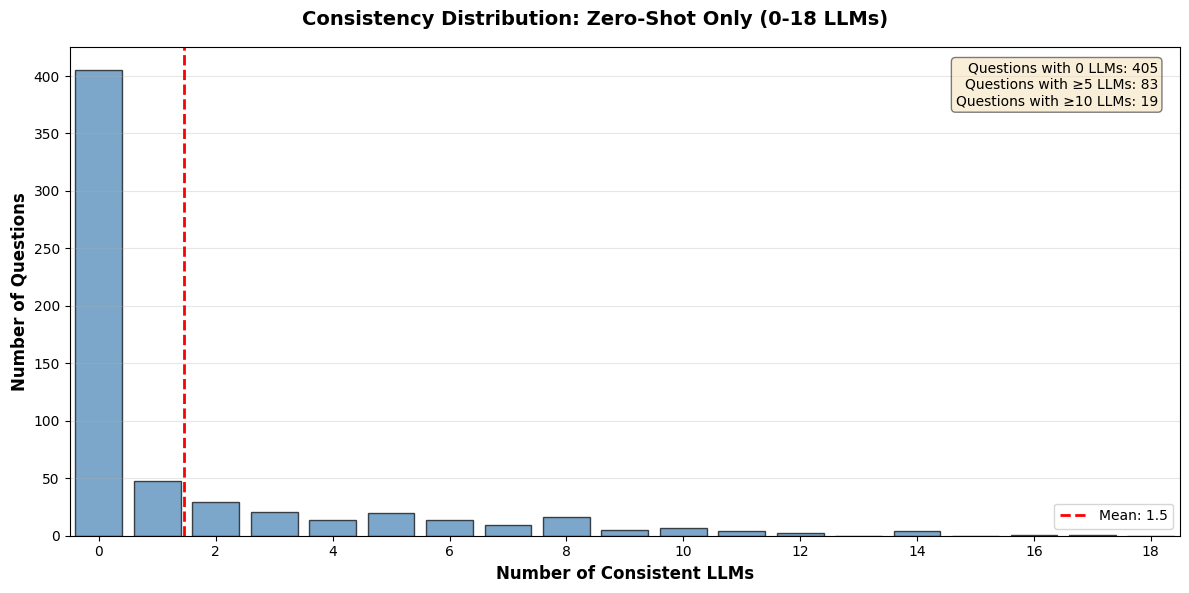

Saved: consistency_distribution_zeroshot.png


In [81]:
# Create figure directory
fig_dir = '../../output/question_analysis/figures'
os.makedirs(fig_dir, exist_ok=True)

# 1. Zero-shot consistency distribution (0-18)
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle('Consistency Distribution: Zero-Shot Only (0-18 LLMs)', 
             fontsize=14, fontweight='bold')

# Prepare data
max_llms = int(df_analysis['llm'].nunique())
counts_zs = consistency_zeroshot['n_consistent_zeroshot'].value_counts().sort_index()
all_counts = {i: 0 for i in range(max_llms + 1)}
all_counts.update(counts_zs.to_dict())

x_values = list(all_counts.keys())
y_values = list(all_counts.values())

ax.bar(x_values, y_values, color='steelblue', alpha=0.7, edgecolor='black', width=0.8)
ax.set_xlabel('Number of Consistent LLMs', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Questions', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, max_llms + 0.5)
ax.set_xticks(range(0, max_llms + 1, 2))
ax.grid(axis='y', alpha=0.3)

# Add statistics
mean_val = consistency_zeroshot['n_consistent_zeroshot'].mean()
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')

textstr = f'Questions with 0 LLMs: {all_counts[0]}\n'
textstr += f'Questions with ≥5 LLMs: {sum(v for k, v in all_counts.items() if k >= 5)}\n'
textstr += f'Questions with ≥10 LLMs: {sum(v for k, v in all_counts.items() if k >= 10)}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'consistency_distribution_zeroshot.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: consistency_distribution_zeroshot.png")

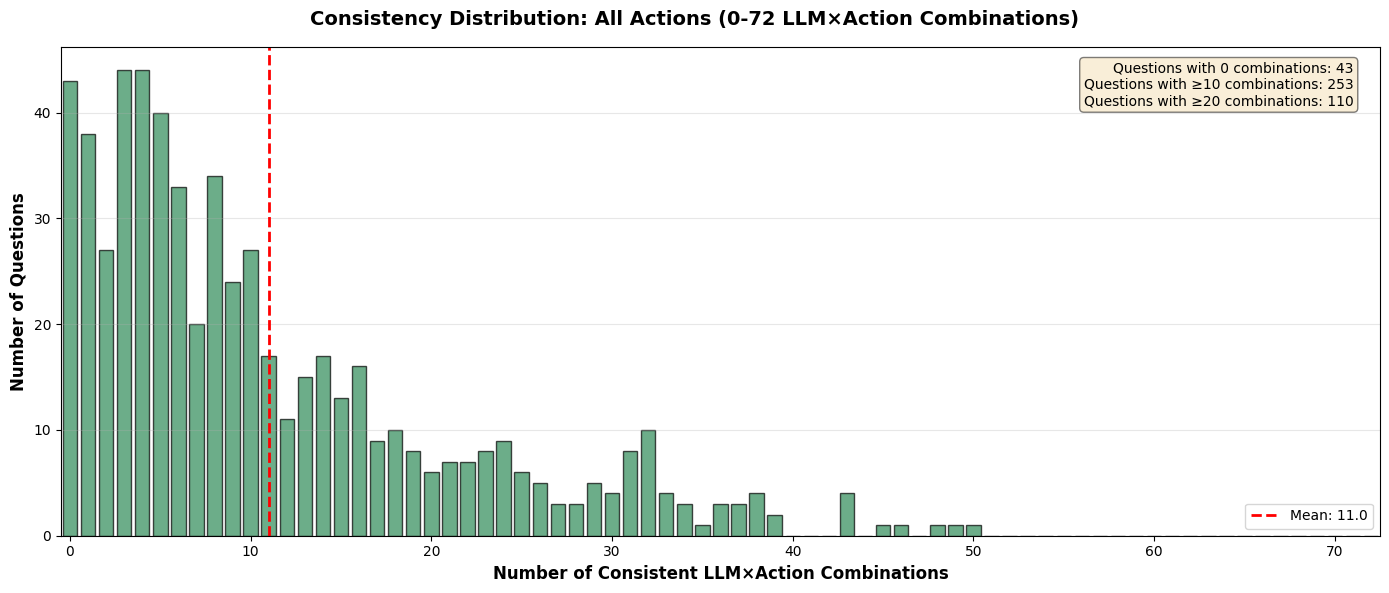

Saved: consistency_distribution_all_actions.png


In [82]:
# 2. All actions consistency distribution (0-72)
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
fig.suptitle('Consistency Distribution: All Actions (0-72 LLM×Action Combinations)', 
             fontsize=14, fontweight='bold')

# Prepare data
max_combinations = int(df_analysis['llm'].nunique() * len(ACTION_PRIORITY))
counts_all = consistency_all_actions['n_consistent_all_actions'].value_counts().sort_index()
all_counts = {i: 0 for i in range(max_combinations + 1)}
all_counts.update(counts_all.to_dict())

x_values = list(all_counts.keys())
y_values = list(all_counts.values())

ax.bar(x_values, y_values, color='seagreen', alpha=0.7, edgecolor='black', width=0.8)
ax.set_xlabel('Number of Consistent LLM×Action Combinations', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Questions', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, max_combinations + 0.5)
ax.set_xticks(range(0, max_combinations + 1, 10))
ax.grid(axis='y', alpha=0.3)

# Add statistics
mean_val = consistency_all_actions['n_consistent_all_actions'].mean()
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')

textstr = f'Questions with 0 combinations: {all_counts[0]}\n'
textstr += f'Questions with ≥10 combinations: {sum(v for k, v in all_counts.items() if k >= 10)}\n'
textstr += f'Questions with ≥20 combinations: {sum(v for k, v in all_counts.items() if k >= 20)}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'consistency_distribution_all_actions.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: consistency_distribution_all_actions.png")

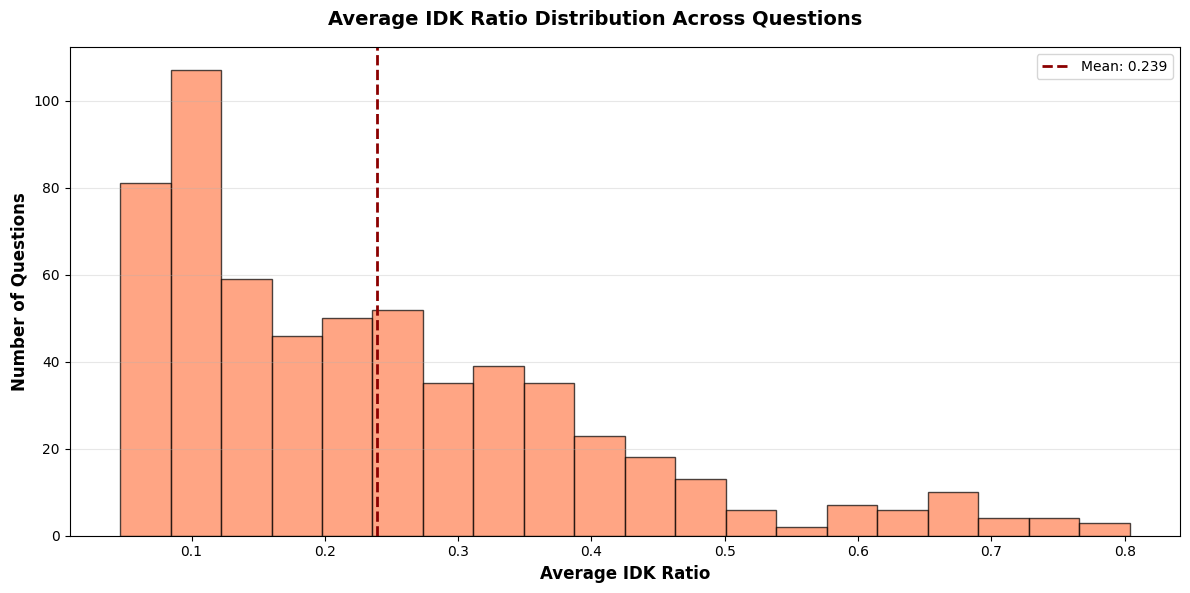

Saved: avg_idk_ratio_distribution.png


In [83]:
# 3. Average IDK Ratio Distribution
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle('Average IDK Ratio Distribution Across Questions', fontsize=14, fontweight='bold')

# Calculate average IDK ratio across all 4 IDK metrics
idk_ratio_cols = [f'{metric}_ratio' for metric in IDK_METRICS]
golden_df['avg_idk_ratio'] = golden_df[idk_ratio_cols].mean(axis=1)

ax.hist(golden_df['avg_idk_ratio'], bins=20, color='coral', alpha=0.7, edgecolor='black')
ax.set_xlabel('Average IDK Ratio', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Questions', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add mean line
mean_val = golden_df['avg_idk_ratio'].mean()
ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'avg_idk_ratio_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: avg_idk_ratio_distribution.png")

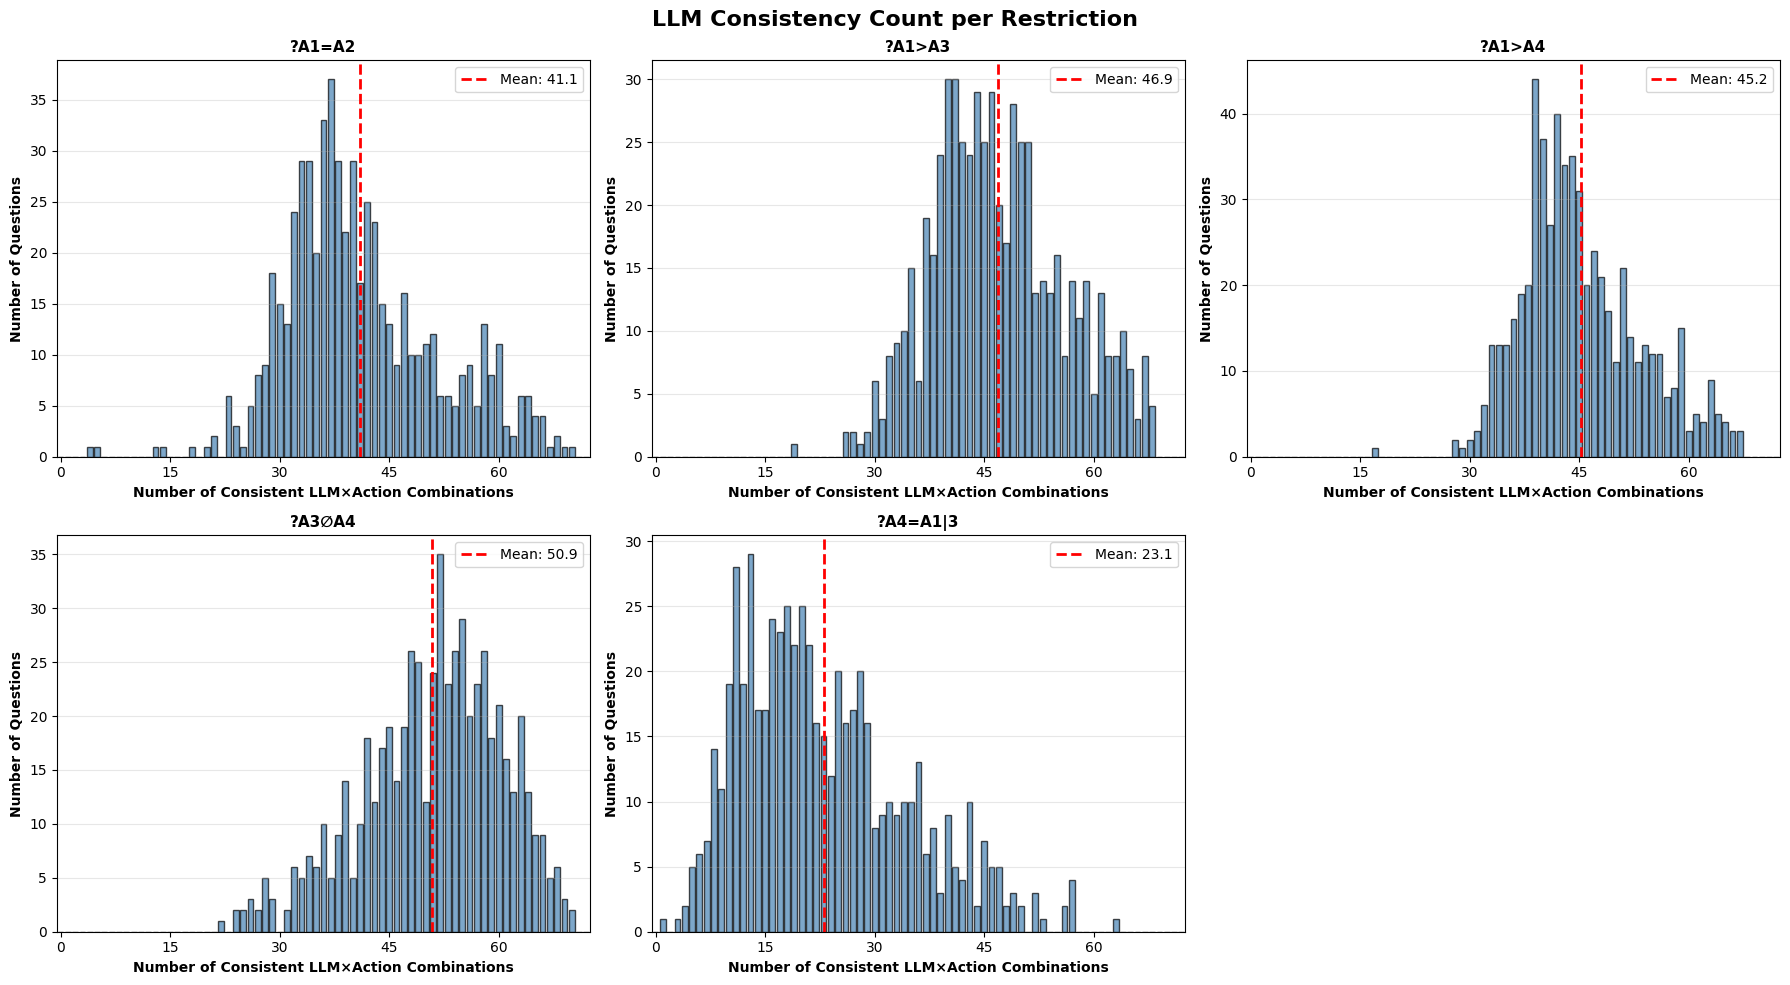

Saved: per_restriction_consistency_distribution.png


In [84]:
# 4. Per-Restriction Consistency Distribution
# For each restriction, count how many LLMs can produce consistent answers (metric = 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('LLM Consistency Count per Restriction', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, metric in enumerate(CONSISTENCY_METRICS):
    # For each question, count how many LLM+action combinations have this metric = 1
    restriction_consistency = df_analysis[df_analysis[metric] == 1].groupby('new_Q_ID').size().reset_index(name='n_consistent')
    
    # Merge with all questions to include those with 0 consistent LLMs
    all_questions_df = pd.DataFrame({'new_Q_ID': all_question_ids})
    restriction_consistency = all_questions_df.merge(restriction_consistency, on='new_Q_ID', how='left')
    restriction_consistency['n_consistent'] = restriction_consistency['n_consistent'].fillna(0).astype(int)
    
    # Plot distribution
    ax = axes[idx]
    max_combinations = int(df_analysis['llm'].nunique() * len(ACTION_PRIORITY))
    counts = restriction_consistency['n_consistent'].value_counts().sort_index()
    all_counts = {i: 0 for i in range(max_combinations + 1)}
    all_counts.update(counts.to_dict())
    
    x_values = list(all_counts.keys())
    y_values = list(all_counts.values())
    
    ax.bar(x_values, y_values, color='steelblue', alpha=0.7, edgecolor='black', width=0.8)
    ax.set_xlabel('Number of Consistent LLM×Action Combinations', fontsize=10, fontweight='bold')
    ax.set_ylabel('Number of Questions', fontsize=10, fontweight='bold')
    ax.set_title(f'{metric}', fontsize=11, fontweight='bold')
    ax.set_xlim(-0.5, max_combinations + 0.5)
    ax.set_xticks(range(0, max_combinations + 1, 15))
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean line
    mean_val = restriction_consistency['n_consistent'].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    ax.legend()

# Hide the 6th subplot (we only have 5 metrics)
axes[5].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'per_restriction_consistency_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: per_restriction_consistency_distribution.png")

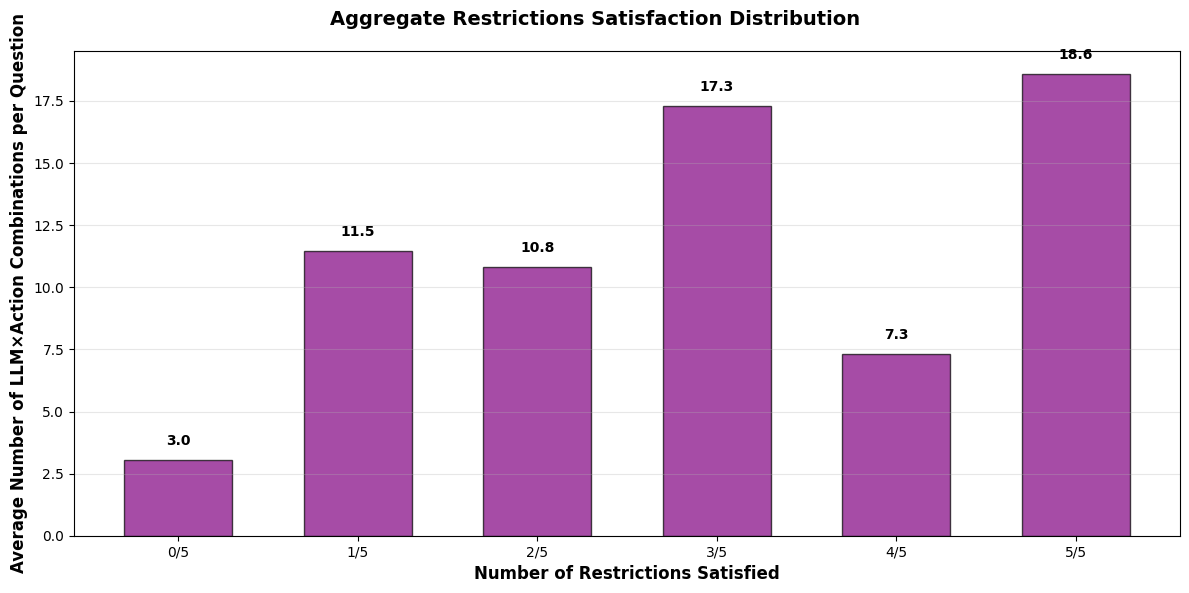

Saved: aggregate_restrictions_distribution.png


In [85]:
# 6. Aggregate Restrictions Distribution
# Show overall distribution of how many restrictions (0-5) are satisfied across all LLM+action combinations
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle('Aggregate Restrictions Satisfaction Distribution', fontsize=14, fontweight='bold')

# For each LLM+action combination, count how many restrictions are satisfied (metric = 1)
df_analysis['n_restrictions_satisfied'] = df_analysis[CONSISTENCY_METRICS].sum(axis=1)

# For each question, get distribution of satisfied restrictions
aggregate_data = []
for q_id in all_question_ids:
    q_data = df_analysis[df_analysis['new_Q_ID'] == q_id]
    # For this question, count how many LLM+action combinations satisfy each count (0-5 restrictions)
    for n_satisfied in range(6):
        count = (q_data['n_restrictions_satisfied'] == n_satisfied).sum()
        aggregate_data.append({
            'new_Q_ID': q_id,
            'n_restrictions_satisfied': n_satisfied,
            'n_combinations': count
        })

aggregate_df = pd.DataFrame(aggregate_data)

# Calculate average number of LLM+action combinations for each restriction count
avg_combinations = aggregate_df.groupby('n_restrictions_satisfied')['n_combinations'].mean()

x_values = list(range(6))
y_values = [avg_combinations.get(i, 0) for i in x_values]

ax.bar(x_values, y_values, color='purple', alpha=0.7, edgecolor='black', width=0.6)
ax.set_xlabel('Number of Restrictions Satisfied', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Number of LLM×Action Combinations per Question', fontsize=12, fontweight='bold')
ax.set_xticks(x_values)
ax.set_xticklabels([f'{i}/5' for i in x_values])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(y_values):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'aggregate_restrictions_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: aggregate_restrictions_distribution.png")

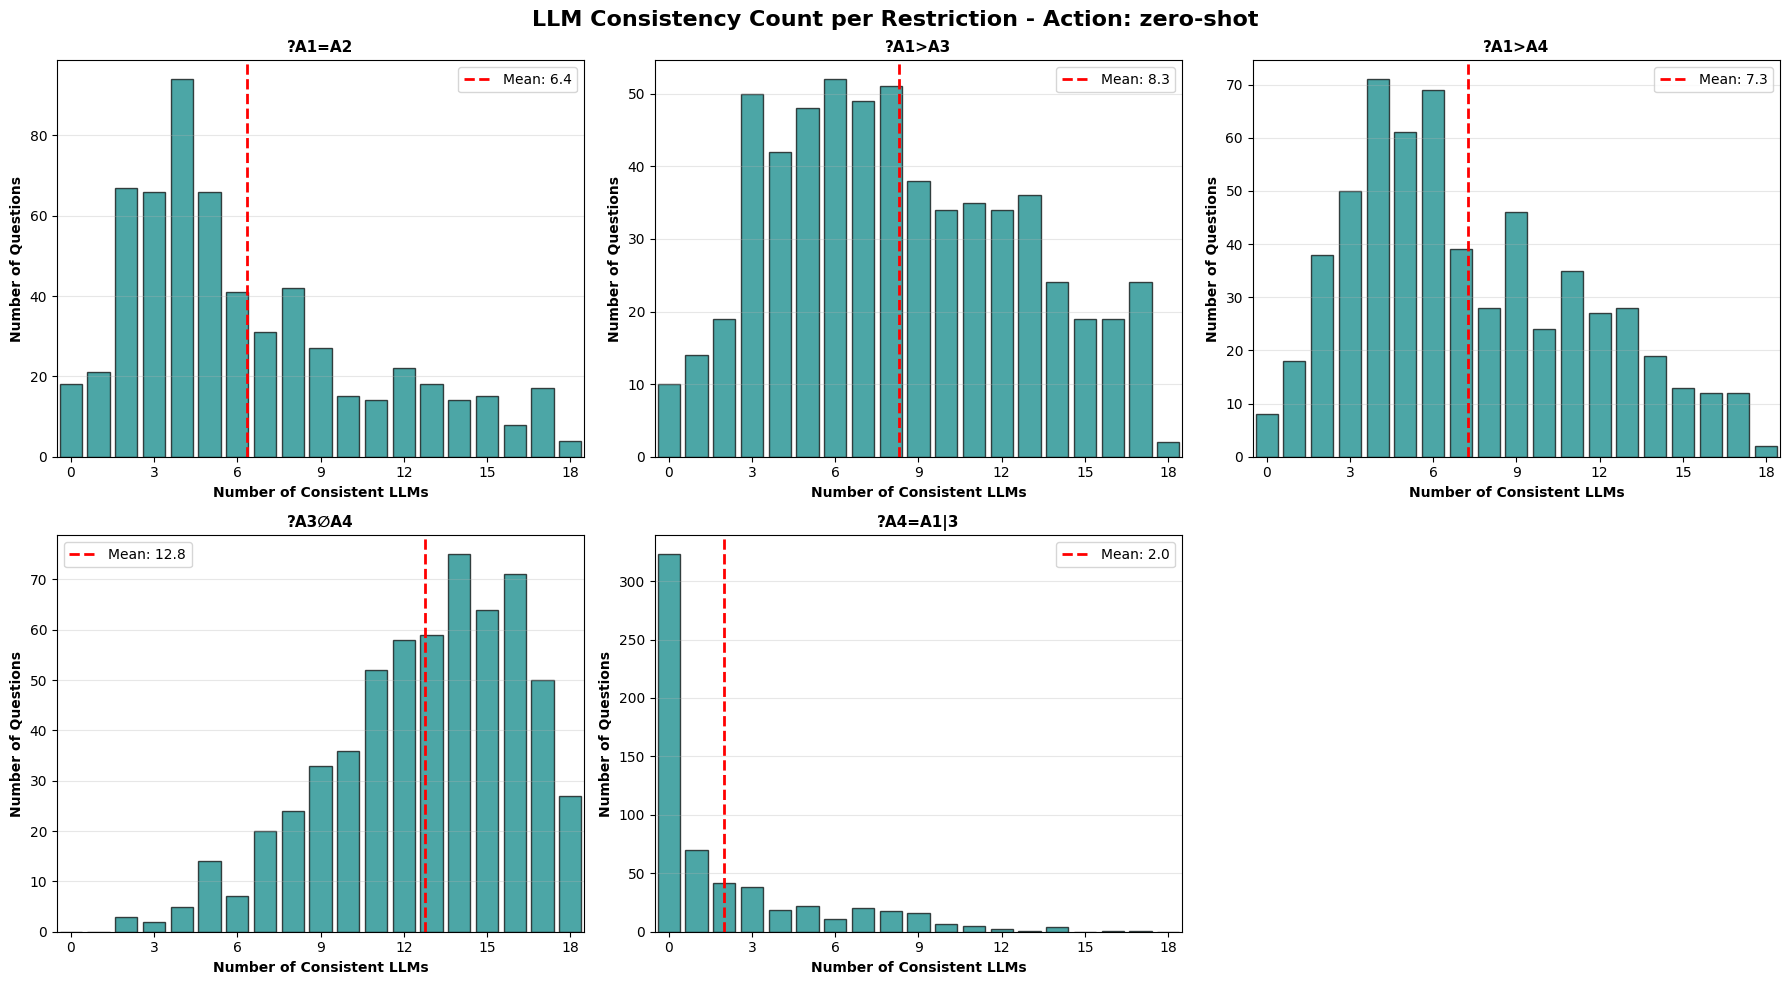

Saved: per_restriction_consistency_by_action_zero-shot.png


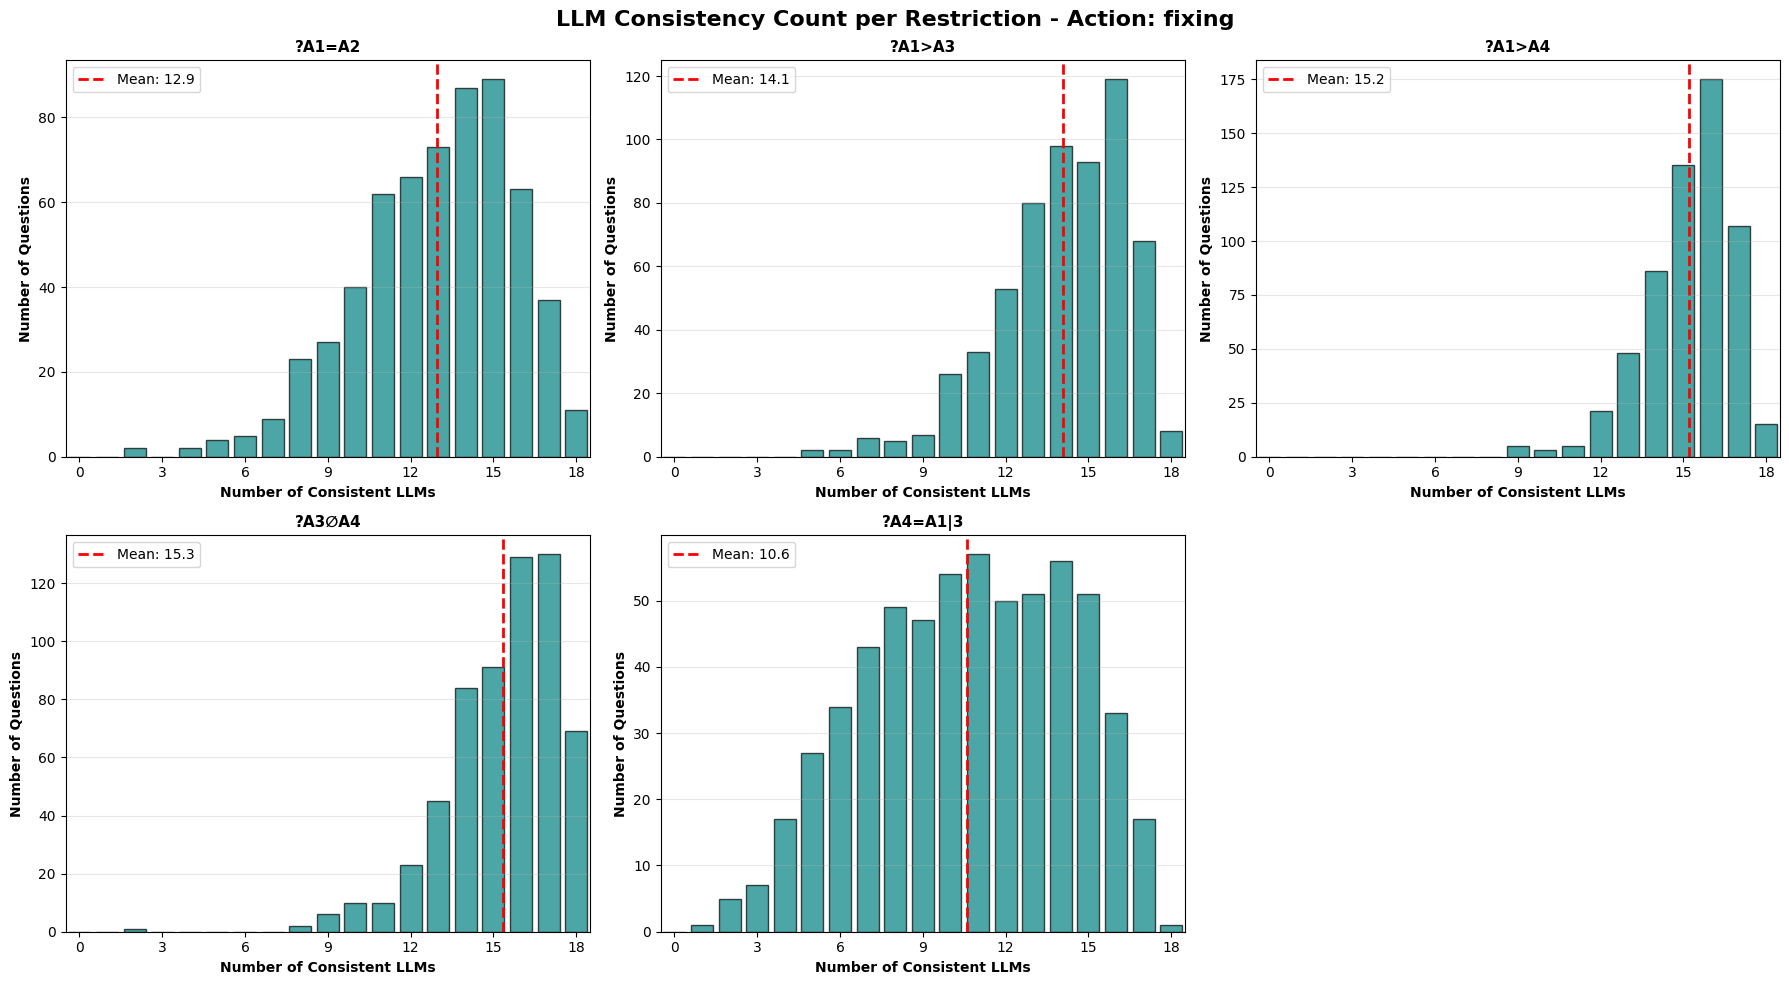

Saved: per_restriction_consistency_by_action_fixing.png


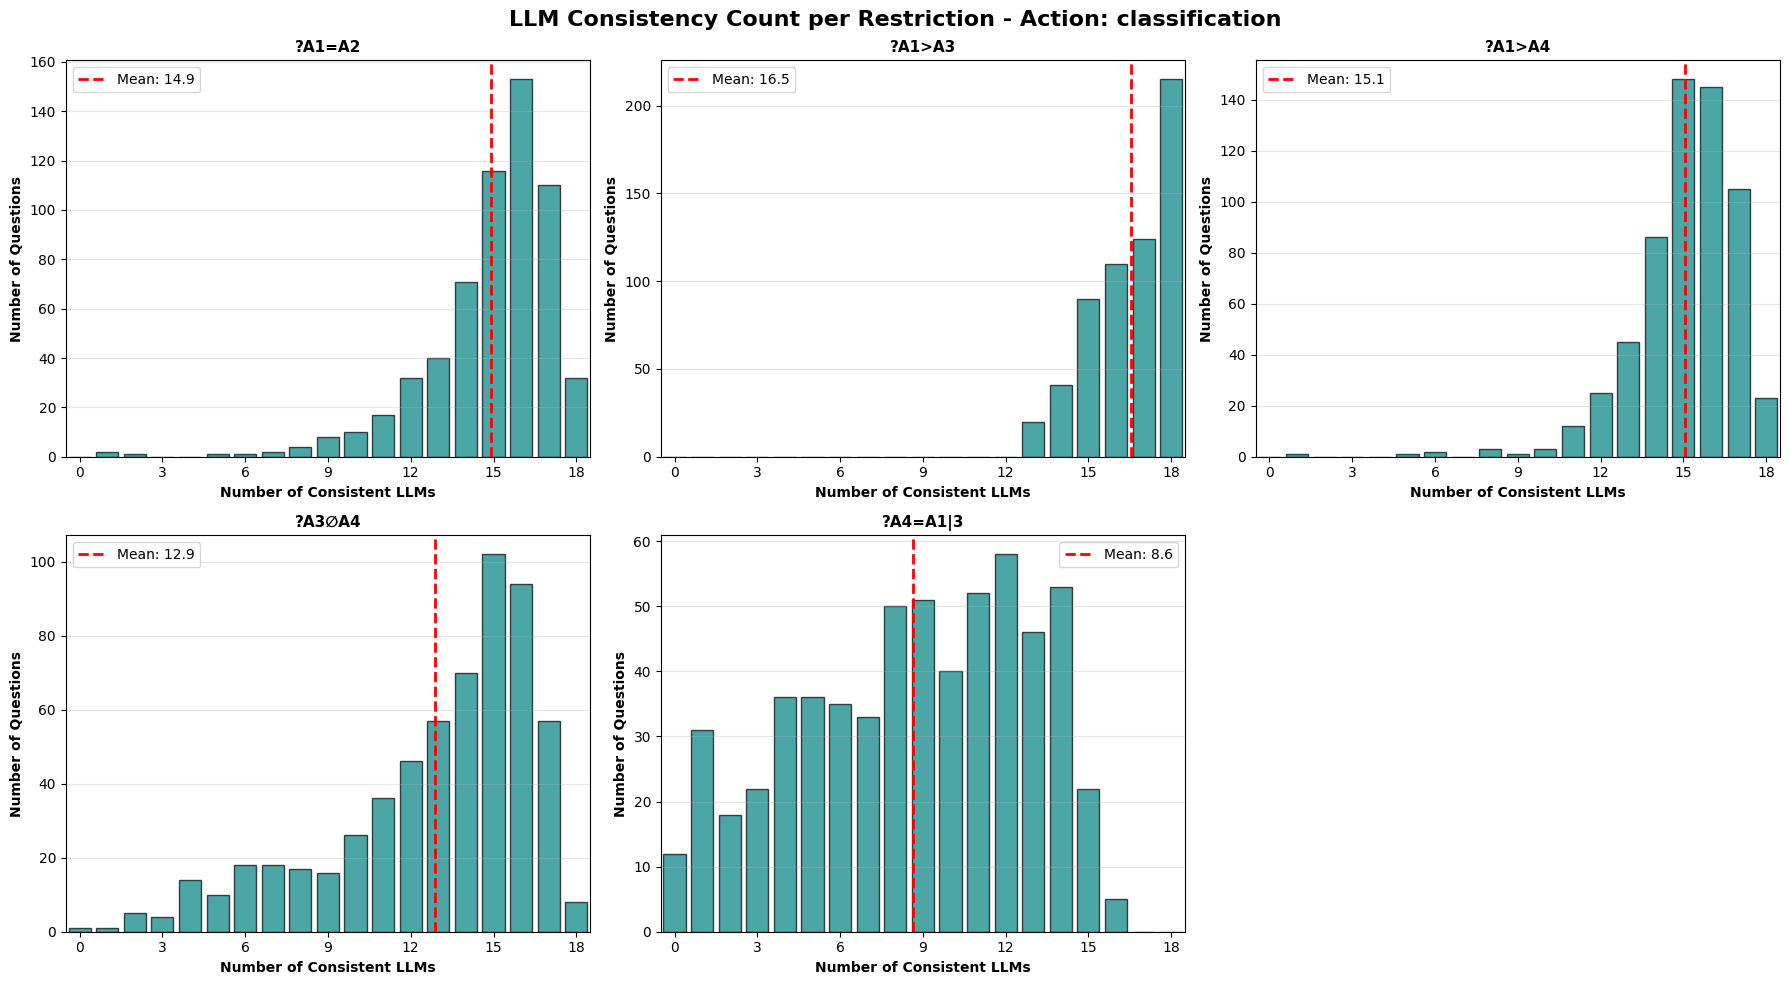

Saved: per_restriction_consistency_by_action_classification.png


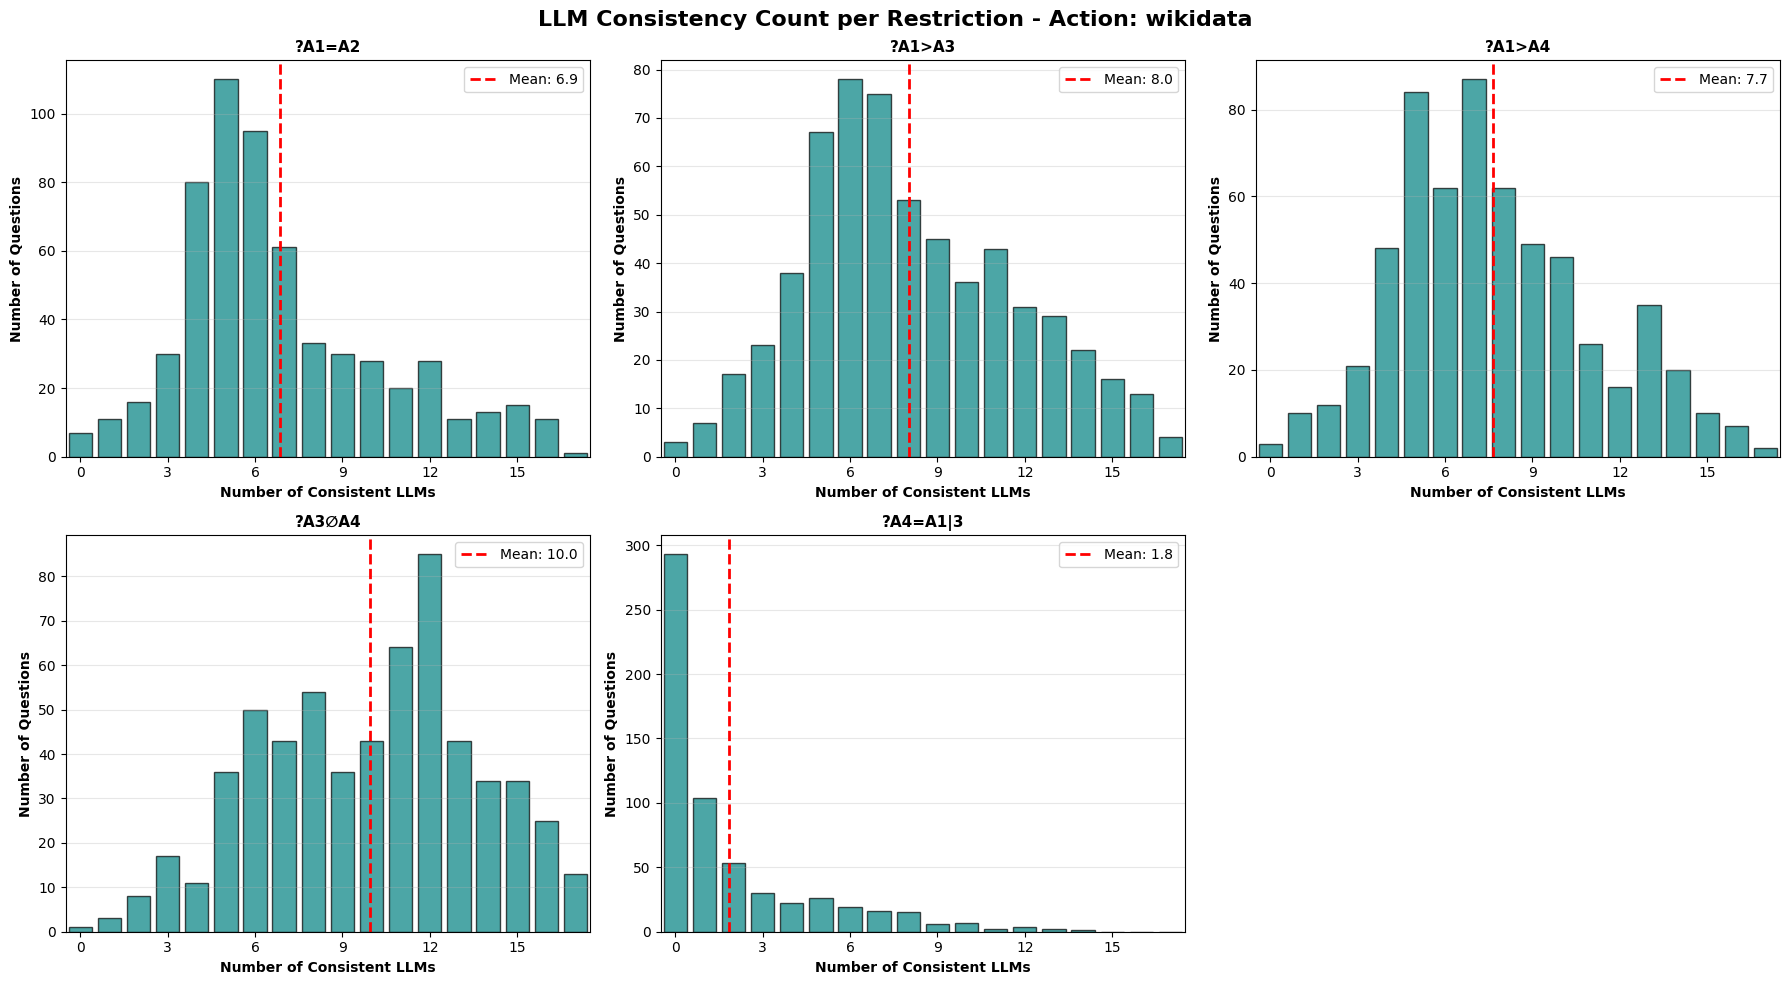

Saved: per_restriction_consistency_by_action_wikidata.png


In [86]:
# 5. Per-Restriction Consistency Distribution by Action
# For each restriction and action, count how many LLMs can produce consistent answers
for action in ACTION_PRIORITY.keys():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'LLM Consistency Count per Restriction - Action: {action}', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    # Filter data for this action
    df_action = df_analysis[df_analysis['action'] == action].copy()
    max_llms = int(df_action['llm'].nunique())
    
    for idx, metric in enumerate(CONSISTENCY_METRICS):
        # For each question, count how many LLMs have this metric = 1 for this action
        restriction_consistency = df_action[df_action[metric] == 1].groupby('new_Q_ID').size().reset_index(name='n_consistent')
        
        # Merge with all questions to include those with 0 consistent LLMs
        all_questions_df = pd.DataFrame({'new_Q_ID': all_question_ids})
        restriction_consistency = all_questions_df.merge(restriction_consistency, on='new_Q_ID', how='left')
        restriction_consistency['n_consistent'] = restriction_consistency['n_consistent'].fillna(0).astype(int)
        
        # Plot distribution
        ax = axes[idx]
        counts = restriction_consistency['n_consistent'].value_counts().sort_index()
        all_counts = {i: 0 for i in range(max_llms + 1)}
        all_counts.update(counts.to_dict())
        
        x_values = list(all_counts.keys())
        y_values = list(all_counts.values())
        
        ax.bar(x_values, y_values, color='teal', alpha=0.7, edgecolor='black', width=0.8)
        ax.set_xlabel('Number of Consistent LLMs', fontsize=10, fontweight='bold')
        ax.set_ylabel('Number of Questions', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric}', fontsize=11, fontweight='bold')
        ax.set_xlim(-0.5, max_llms + 0.5)
        ax.set_xticks(range(0, max_llms + 1, 3))
        ax.grid(axis='y', alpha=0.3)
        
        # Add mean line
        mean_val = restriction_consistency['n_consistent'].mean()
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
        ax.legend()
    
    # Hide the 6th subplot (we only have 5 metrics)
    axes[5].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f'per_restriction_consistency_by_action_{action}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: per_restriction_consistency_by_action_{action}.png")

## Step 9: Analyze Most/Least Consistent and IDK Questions

Identify the question quads that are:
- Most consistent (highest agreement across LLMs)
- Most inconsistent (lowest agreement across LLMs)
- Most IDK responses
- Least IDK responses

In [87]:
# Analyze most/least consistent questions
print("=" * 80)
print("MOST/LEAST CONSISTENT QUESTION QUADS")
print("=" * 80)

# Sort by overall consistency ratio
golden_df_sorted_consistency = golden_df.sort_values('overall_consistency_ratio', ascending=False)

print("\n TOP 10 MOST CONSISTENT QUESTIONS:")
print("=" * 80)
for idx, (_, row) in enumerate(golden_df_sorted_consistency.head(10).iterrows(), 1):
    print(f"\n{idx}. Question ID: {row['new_Q_ID']}")
    print(f"   Dataset: {row['dataset']}")
    print(f"   Overall Consistency Ratio: {row['overall_consistency_ratio']:.3f}")
    print(f"   Consistent LLMs (zero-shot): {row['n_consistent_zeroshot']}")
    print(f"   Consistent LLM×Actions (all): {row['n_consistent_all_actions']}")
    print(f"   Q1: {row['Q1']}")
    print(f"   Q2: {row['Q2']}")
    print(f"   Q3: {row['Q3']}")
    print(f"   Q4: {row['Q4']}")

print("\n\n" + "=" * 80)
print(" TOP 10 MOST INCONSISTENT QUESTIONS:")
print("=" * 80)
for idx, (_, row) in enumerate(golden_df_sorted_consistency.tail(10).iterrows(), 1):
    print(f"\n{idx}. Question ID: {row['new_Q_ID']}")
    print(f"   Dataset: {row['dataset']}")
    print(f"   Overall Consistency Ratio: {row['overall_consistency_ratio']:.3f}")
    print(f"   Consistent LLMs (zero-shot): {row['n_consistent_zeroshot']}")
    print(f"   Consistent LLM×Actions (all): {row['n_consistent_all_actions']}")
    print(f"   Q1: {row['Q1']}")
    print(f"   Q2: {row['Q2']}")
    print(f"   Q3: {row['Q3']}")
    print(f"   Q4: {row['Q4']}")

MOST/LEAST CONSISTENT QUESTION QUADS

 TOP 10 MOST CONSISTENT QUESTIONS:

1. Question ID: synthetic-78
   Dataset: synthetic
   Overall Consistency Ratio: 0.704
   Consistent LLMs (zero-shot): 17
   Consistent LLM×Actions (all): 50
   Q1: What are the constituent countries of the UK?
   Q2: Which countries make up the United Kingdom?
   Q3: What are the constituent countries of the UK located on the island of Great Britain?
   Q4: What are the constituent countries of the UK excluding those located on the island of Great Britain?

2. Question ID: spinach-35
   Dataset: spinach
   Overall Consistency Ratio: 0.700
   Consistent LLMs (zero-shot): 14
   Consistent LLM×Actions (all): 49
   Q1: Who were the Vice Presidents under Lincoln?
   Q2: Who were the Vice Presidents of Lincoln?
   Q3: Who was the Vice President under Abraham Lincoln during his first term?
   Q4: Who was the Vice President under Abraham Lincoln during his second term?

3. Question ID: synthetic-42
   Dataset: synthetic

In [88]:
# Analyze most/least IDK questions
print("\n\n" + "=" * 80)
print("MOST/LEAST IDK QUESTION QUADS")
print("=" * 80)

# Sort by average IDK ratio (already calculated in visualization step)
golden_df_sorted_idk = golden_df.sort_values('avg_idk_ratio', ascending=False)

print("\n TOP 10 QUESTIONS WITH MOST IDK RESPONSES:")
print("=" * 80)
for idx, (_, row) in enumerate(golden_df_sorted_idk.head(10).iterrows(), 1):
    print(f"\n{idx}. Question ID: {row['new_Q_ID']}")
    print(f"   Dataset: {row['dataset']}")
    print(f"   Average IDK Ratio: {row['avg_idk_ratio']:.3f}")
    print(f"   IDK Ratios - A1: {row['idk_A1_ratio']:.3f}, A2: {row['idk_A2_ratio']:.3f}, A3: {row['idk_A3_ratio']:.3f}, A4: {row['idk_A4_ratio']:.3f}")
    print(f"   Overall Consistency Ratio: {row['overall_consistency_ratio']:.3f}")
    print(f"   Q1: {row['Q1']}")
    print(f"   Q2: {row['Q2']}")
    print(f"   Q3: {row['Q3']}")
    print(f"   Q4: {row['Q4']}")

print("\n\n" + "=" * 80)
print("TOP 10 QUESTIONS WITH LEAST IDK RESPONSES:")
print("=" * 80)
for idx, (_, row) in enumerate(golden_df_sorted_idk.tail(10).iterrows(), 1):
    print(f"\n{idx}. Question ID: {row['new_Q_ID']}")
    print(f"   Dataset: {row['dataset']}")
    print(f"   Average IDK Ratio: {row['avg_idk_ratio']:.3f}")
    print(f"   IDK Ratios - A1: {row['idk_A1_ratio']:.3f}, A2: {row['idk_A2_ratio']:.3f}, A3: {row['idk_A3_ratio']:.3f}, A4: {row['idk_A4_ratio']:.3f}")
    print(f"   Overall Consistency Ratio: {row['overall_consistency_ratio']:.3f}")
    print(f"   Q1: {row['Q1']}")
    print(f"   Q2: {row['Q2']}")
    print(f"   Q3: {row['Q3']}")
    print(f"   Q4: {row['Q4']}")



MOST/LEAST IDK QUESTION QUADS

 TOP 10 QUESTIONS WITH MOST IDK RESPONSES:

1. Question ID: qawiki-140
   Dataset: qawiki
   Average IDK Ratio: 0.804
   IDK Ratios - A1: 0.829, A2: 0.786, A3: 0.871, A4: 0.729
   Overall Consistency Ratio: 0.000
   Q1: Which writers speak French, Arabic and Japanese?
   Q2: Which authors speak French, Arabic and Japanese?
   Q3: Which writers speak English, French, Arabic and Japanese?
   Q4: Which writers speak French, Arabic, and English but do not speak Japanese?

2. Question ID: qawiki-39
   Dataset: qawiki
   Average IDK Ratio: 0.775
   IDK Ratios - A1: 0.771, A2: 0.729, A3: 0.843, A4: 0.757
   Overall Consistency Ratio: 0.000
   Q1: What papers did Amrapali Zaveri publish?
   Q2: What papers has Amrapali Zaveri published?
   Q3: What papers did Amrapali Zaveri publish as first author?
   Q4: What papers did Amrapali Zaveri write but not as first author?

3. Question ID: LC-QuAD-59
   Dataset: LC-QuAD
   Average IDK Ratio: 0.773
   IDK Ratios - A1